## Milestone 26: UKESM1-2-LL Ocean Mixed Layer Analysis

### Contact:
Ollie Tooth (oliver.tooth@noc.ac.uk)

In [1]:
import glob
import gsw
import cftime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

/g100/home/userexternal/otooth00/.conda/envs/env_optimesm/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
def open_diagnostic_dataset(filepath: str, offset: int = 0):
    """
    Open NEMO Pipeline Diagnostic Dataset.

    Parameters
    ----------
    filepath : str
        Filepath to NEMO Pipeline diagnostics stored in local netCDF file.
    offset : int
        Offset used to adjust (add) time_counter coordinate.

    Returns
    -------
    ds : xr.Dataset
    """
    # Define CF-timecoder:
    time_coder = xr.coders.CFDatetimeCoder(time_unit="s")
    # Open diagnostic netCDF dataset:
    ds = xr.open_dataset(filepath, decode_times=time_coder)
    if "time" in ds.coords:
        ds = ds.rename({"time":"time_counter"})

    # Update time_counter coord using cftime:
    new_time_counter = [
        cftime.Datetime360Day(t.year - ds['time_counter'].values[0].year + offset,
                              t.month,
                              t.day
                              )
        for t in ds['time_counter'].values
    ]
    ds = ds.assign_coords(time_counter=("time_counter", new_time_counter))

    return ds

In [3]:
# -- Open UKESM1-2-LL esm-piControl -- #
filedir="/g100_work/optim_IAC/research/noc/otooth/OptimESM/data/UKESM1-2-LL/esm-piControl"
filepath=f"{filedir}/r1i1p1f1/Omon/mlotst/gn/v20241002/mlotst_Omon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_*.nc"

time_coder = xr.coders.CFDatetimeCoder(time_unit="s")
ds_gridT = xr.open_mfdataset(filepath, decode_times=time_coder, data_vars='all')
ds_gridT

<xarray.Dataset> Size: 39GB
Dimensions:             (time: 4812, bnds: 2, j: 330, i: 360, vertices: 4)
Coordinates:
  * time                (time) object 38kB 2100-01-16 00:00:00 ... 2500-12-16...
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 324 325 326 327 328 329
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) object 77kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    vertices_latitude   (time, j, i, vertices) float64 18GB dask.array<chunksize=(600, 330, 360, 4), meta=np.ndarray>
    vertices_longitude  (time, j, i, vertices) float64 18GB dask.array<chunksize=(600, 330, 360, 4), meta=np.ndarray>
    mlotst              (time, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
Attributes: (12/39)
    Conventions:           CF-1.7 CMIP-6.2
    activity_id:           TerraFIRMA
    branch_method:         no parent
    creation_date:         2024-06-18T10:54:44Z
    cv_version:            GCModelDev v0.0.17
    data_specs_version:    GCModelDev v0.0.17
    ...                    ...
    variable_id:           mlotst
    variable_name:         mlotst
    variant_label:         r1i1p1f1
    license:               GCModelDev model data is licensed under the Open G...
    cmor_version:          3.7.3
    tracking_id:           GCMODELDEV/26332c1a-baeb-464e-a943-023579378a2b

In [4]:
# -- Open UKESM1-2-LL Convection Region Diagnostic Outputs -- #
filedir = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/thetao_so_ml"
# esm-piControl:
ds_ukesm1_piControl = open_diagnostic_dataset(f"{filedir}/UKESM1-2-LL_esm-piControl_r1i1p1f1_thetao_so_ml_2100-01-2500-12.nc")

# esm-up2p0 [ramp-up]:
ds_ukesm1_up2p0 = open_diagnostic_dataset(f"{filedir}/UKESM1-2-LL_esm-up2p0_r1i1p1f1_thetao_so_ml_1850-01-2139-12.nc")

ds_ukesm1_up2p0


<xarray.Dataset> Size: 16MB
Dimensions:              (time_counter: 3480, k: 75, j: 330, i: 360)
Coordinates:
  * time_counter         (time_counter) object 28kB 0000-01-16 00:00:00 ... 0...
  * k                    (k) int64 600B 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75
    deptht               (k) float64 600B ...
    variable             <U2 8B ...
    gphit                (j, i) float64 950kB ...
    glamt                (j, i) float64 950kB ...
Dimensions without coordinates: j, i
Data variables: (12/14)
    volcello_LabSea      (time_counter, k) float64 2MB ...
    thetao_con_LabSea    (time_counter, k) float64 2MB ...
    so_abs_LabSea        (time_counter, k) float64 2MB ...
    mlotst_wmean_LabSea  (time_counter) float64 28kB ...
    mlotst_vol_LabSea    (time_counter) float64 28kB ...
    volcello_IrmSea      (time_counter, k) float64 2MB ...
    ...                   ...
    mlotst_wmean_IrmSea  (time_counter) float64 28kB ...
    mlotst_vol_IrmSea    (time_counter) float64 28kB ...
    mask_LabSea          (j, i) int64 950kB ...
    mask_IrmSea          (j, i) int64 950kB ...
    cp0                  float64 8B ...
    rho0                 int64 8B ...

In [5]:
# -- Compute TEOS-10 Potential Density -- #
ds_ukesm1_piControl['sigma0_LabSea'] = gsw.sigma0(CT=ds_ukesm1_piControl['thetao_con_LabSea'], SA=ds_ukesm1_piControl['so_abs_LabSea'])
ds_ukesm1_up2p0['sigma0_LabSea'] = gsw.sigma0(CT=ds_ukesm1_up2p0['thetao_con_LabSea'], SA=ds_ukesm1_up2p0['so_abs_LabSea'])

ds_ukesm1_piControl['sigma0_IrmSea'] = gsw.sigma0(CT=ds_ukesm1_piControl['thetao_con_IrmSea'], SA=ds_ukesm1_piControl['so_abs_IrmSea'])
ds_ukesm1_up2p0['sigma0_IrmSea'] = gsw.sigma0(CT=ds_ukesm1_up2p0['thetao_con_IrmSea'], SA=ds_ukesm1_up2p0['so_abs_IrmSea'])

### Defining Labrador Sea & Irminger Sea Deep Convection Regions:

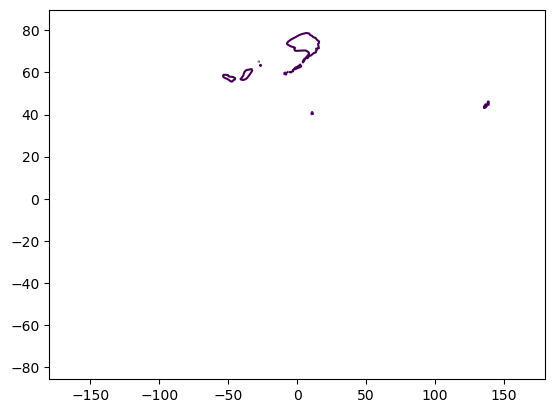

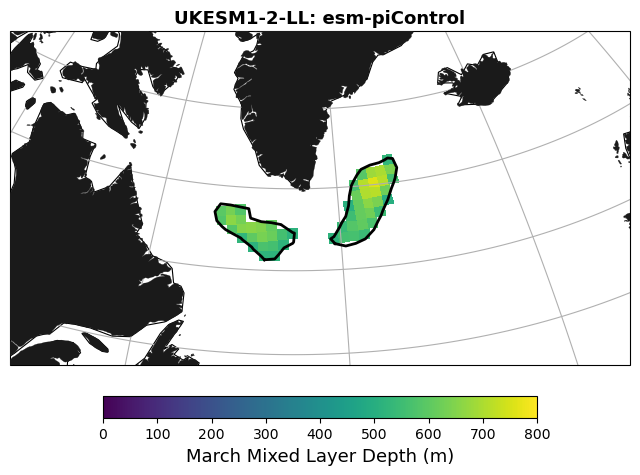

In [6]:
# -- Calculate time-mean esm-piControl mixed layer + 500-m contour -- #
mlotst_mmean = ds_gridT['mlotst'].sel(time=ds_gridT['time'].dt.month.isin([3])).mean(dim='time')
cs = plt.contour(ds_gridT['longitude'], ds_gridT['latitude'], mlotst_mmean, levels=[500])

# -- Create a figure with an orthographic (globe) projection -- #
fig = plt.figure(figsize=(8, 8))
proj = ccrs.Orthographic(central_longitude=-45, central_latitude=40)  # change center
ax = plt.axes(projection=proj)
ax.set_extent([-70, -15, 47, 68])
ax.coastlines(resolution='110m', linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='0.1', edgecolor='0.1', linewidth=0.2, zorder=4)
ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False)

# -- Labrador Sea -- #
# Plot the DataArray. Use transform=ccrs.PlateCarree since data coords are lon/lat
c = plt.pcolormesh(ds_gridT['longitude'], ds_gridT['latitude'], mlotst_mmean.where(ds_ukesm1_piControl.mask_LabSea),
                   cmap='viridis', shading='auto', zorder=1, transform=ccrs.PlateCarree(),
                   vmin=0, vmax=800)

# 500-m time-mean March Mixed Layer Depth Polygon:
ml_poly = cs.allsegs[0][3]
lon_ml_poly = np.array([coord[0] for coord in ml_poly], dtype=np.float32)
lat_ml_poly = np.array([coord[1] for coord in ml_poly], dtype=np.float32)
# Overlay the Labrador Sea nest boundary & 500m MLD contour:
plt.plot(lon_ml_poly, lat_ml_poly, color='k', lw=2, transform=ccrs.PlateCarree(), zorder=5)

# -- Irminger Sea -- #
# Plot the DataArray. Use transform=ccrs.PlateCarree since data coords are lon/lat
c = plt.pcolormesh(ds_gridT['longitude'], ds_gridT['latitude'], mlotst_mmean.where(ds_ukesm1_piControl.mask_IrmSea),
                   cmap='viridis', shading='auto', zorder=1, transform=ccrs.PlateCarree(),
                   vmin=0, vmax=800)

# 500-m time-mean March Mixed Layer Depth Polygon:
ml_poly = cs.allsegs[0][4]
lon_ml_poly = np.array([coord[0] for coord in ml_poly], dtype=np.float32)
lat_ml_poly = np.array([coord[1] for coord in ml_poly], dtype=np.float32)
# Overlay the Irminger Sea nest boundary & 500m MLD contour:
plt.plot(lon_ml_poly, lat_ml_poly, color='k', lw=2, transform=ccrs.PlateCarree(), zorder=5)

# Add colorbar and title
ax.set_title("UKESM1-2-LL: esm-piControl", fontsize=13, fontweight='bold')
cb = plt.colorbar(c, orientation="horizontal", pad=0.05, shrink=0.7)
cb.set_label("March Mixed Layer Depth (m)", fontsize=13)

# Save Figure:
plt.savefig("/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/figures/M26/fig_M26_esm-piControl_ML_regions.png", bbox_inches='tight', dpi=600)


### Labrador Sea

In [7]:
# -- Calculating Mixed Layer Depth (0.03 kg m-3 threshold criterion from 10 m potential density) directly from profiles -- #
# Labrador Sea:
mask = (ds_ukesm1_up2p0['sigma0_LabSea'] - ds_ukesm1_up2p0['sigma0_LabSea'].isel(k=7)) > 0.03
mld_LabSea = ds_ukesm1_up2p0.deptht.where(mask).min(dim='k')

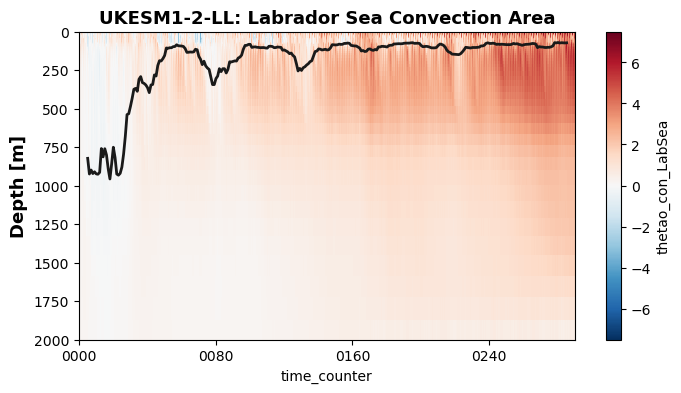

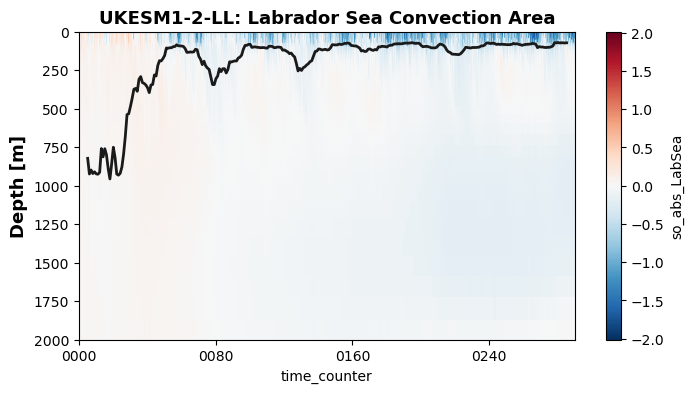

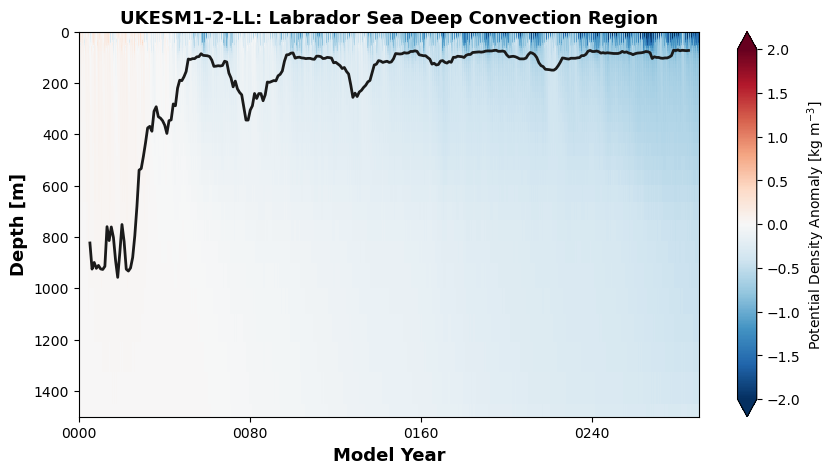

In [8]:
# Calculate monthly climatology of conservative temperature in esm-piControl:
thetao_con_LabSea_piControl_monthly = (ds_ukesm1_piControl['thetao_con_LabSea']
                                       .groupby(ds_ukesm1_piControl['time_counter'].dt.month)
                                       .mean()
                                       )
# Calculate monthly climatology of absolute salinity in esm-piControl:
so_abs_LabSea_piControl_monthly = (ds_ukesm1_piControl['so_abs_LabSea']
                                   .groupby(ds_ukesm1_piControl['time_counter'].dt.month)
                                   .mean()
                                   )
# Calculate monthly climatology of potential density in esm-piControl:
sigma0_LabSea_piControl_monthly = (ds_ukesm1_piControl['sigma0_LabSea']
                                   .groupby(ds_ukesm1_piControl['time_counter'].dt.month)
                                   .mean()
                                   )
# -- Conservative Temperature -- #
plt.figure(figsize=(8, 4))
((ds_ukesm1_up2p0['thetao_con_LabSea'].groupby(ds_ukesm1_up2p0['time_counter'].dt.month) - thetao_con_LabSea_piControl_monthly)
 .transpose()
 .plot(yincrease=False, y='deptht')
 )

# March Mixed Layer Depth [10-year rolling mean]:
mld_LabSea.isel(time_counter=slice(2, None, 12)).rolling(time_counter=10, center=True).mean().plot(lw=2, color='0.1')

plt.title('UKESM1-2-LL: Labrador Sea Convection Area', fontweight='bold', fontsize=13)
plt.ylabel('Depth [m]', fontweight='bold', fontsize=13)
plt.ylim([2000, 0])

# -- Absolute Salinity -- #
plt.figure(figsize=(8, 4))
((ds_ukesm1_up2p0['so_abs_LabSea'].groupby(ds_ukesm1_up2p0['time_counter'].dt.month) - so_abs_LabSea_piControl_monthly)
 .transpose()
 .plot(yincrease=False, y='deptht')
 )

# March Mixed Layer Depth [10-year rolling mean]:
mld_LabSea.isel(time_counter=slice(2, None, 12)).rolling(time_counter=10, center=True).mean().plot(lw=2, color='0.1')

plt.title('UKESM1-2-LL: Labrador Sea Convection Area', fontweight='bold', fontsize=13)
plt.ylabel('Depth [m]', fontweight='bold', fontsize=13)
plt.ylim([2000, 0])

# -- Absolute Salinity -- #
plt.figure(figsize=(10, 5))
((ds_ukesm1_up2p0['sigma0_LabSea'].groupby(ds_ukesm1_up2p0['time_counter'].dt.month) - sigma0_LabSea_piControl_monthly)
 .transpose()
 .plot(yincrease=False, y='deptht', vmin=-2, vmax=2, cmap='RdBu_r', extend='both', cbar_kwargs={'label': 'Potential Density Anomaly [kg m$^{-3}$]'})
 )

# March Mixed Layer Depth [10-year rolling mean]:
mld_LabSea.isel(time_counter=slice(2, None, 12)).rolling(time_counter=10, center=True).mean().plot(lw=2, color='0.1')

plt.title('UKESM1-2-LL: Labrador Sea Deep Convection Region', fontweight='bold', fontsize=13)
plt.xlabel('Model Year', fontweight='bold', fontsize=13)
plt.ylabel('Depth [m]', fontweight='bold', fontsize=13)
plt.ylim([1500, 0])
# Save Figure:
plt.savefig("/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/figures/M26/fig_M26_LabSea_MLD_sigma0.png", bbox_inches='tight', dpi=600)


### Labrador Sea: Decomposition of Potential Density Changes:

In [9]:
rho0 = 1025 # kg m-3
p_LabSea = gsw.conversions.p_from_z(z=-ds_ukesm1_up2p0['deptht'], lat=ds_ukesm1_up2p0['gphit'].where(ds_ukesm1_up2p0['mask_LabSea']).mean())

In [10]:
def compute_dsigma0_linear_EOS(thetao_con_in: np.ndarray,
                               thetao_con_out: np.ndarray,
                               so_abs_in: np.ndarray,
                               so_abs_out: np.ndarray,
                               p: np.ndarray
                               ) -> tuple([np.ndarray, np.ndarray, np.ndarray, np.ndarray]):
    """
    Compute Net Potential Density Change due to Diathermal and Diahaline Transformations
    using a Linearised Equation of State for Seawater:
    """
    # Absolute Salinity Change:
    dso_abs = so_abs_out - so_abs_in
    # Conservative Temperature Change:
    dthetao_con = thetao_con_out - thetao_con_in

    # Thermal Expansion Coefficient, alpha:
    alpha = gsw.density.alpha(CT=(thetao_con_in + thetao_con_out) / 2, SA=(so_abs_in + so_abs_out) / 2, p=p)
    # Haline Contraction Coefficient, beta
    beta = gsw.density.beta(CT=(thetao_con_in + thetao_con_out) / 2, SA=(so_abs_in + so_abs_out) / 2, p=p)

    # Potential Density [In, Out]:
    sigma0_in = gsw.density.sigma0(CT=thetao_con_in, SA=so_abs_in)
    sigma0_out = gsw.density.sigma0(CT=thetao_con_out, SA=so_abs_out)
    # Potential Density Change:
    dsigma0_actual = sigma0_out - sigma0_in
    # dsigma0_actual.name = 'dsigma0_actual'

    # Estimated Total Potential Density Change using Linear EOS:
    dsigma0_approx = rho0 * ((-alpha * dthetao_con) + (beta * dso_abs))
    # dsigma0_approx.name = 'dsigma0_approx'

    # Estimated diathermal contribution to net density change:
    dsigma0_diathermal_approx = rho0 * (-alpha * dthetao_con)
    # dsigma0_diathermal_approx.name = 'dsigma0_diathermal_approx'

    # Estimated diahaline contribution to net density change:
    dsigma0_diahaline_approx = rho0 * (beta * dso_abs)
    # dsigma0_diahaline_approx.name = 'dsigma0_diahaline_approx'

    return dsigma0_actual, dsigma0_approx, dsigma0_diathermal_approx, dsigma0_diahaline_approx


In [11]:
t_size = ds_ukesm1_up2p0.time_counter[slice(2, -12, 12)].size
k_size = ds_ukesm1_up2p0.k.size

dsigma0_actual = np.zeros((t_size, k_size))
dsigma0_approx = np.zeros((t_size, k_size))
dsigma0_approx_diathermal = np.zeros((t_size, k_size))
dsigma0_approx_diahaline = np.zeros((t_size, k_size))

for nk in range(75):
    dsigma0_actual[:, nk], dsigma0_approx[:, nk], dsigma0_approx_diathermal[:, nk], dsigma0_approx_diahaline[:, nk] = compute_dsigma0_linear_EOS(thetao_con_in=ds_ukesm1_up2p0['thetao_con_LabSea'].isel(k=nk, time_counter=slice(2, -12, 12)).values,
                                                                  thetao_con_out=ds_ukesm1_up2p0['thetao_con_LabSea'].isel(k=nk, time_counter=slice(14, None, 12)).values,
                                                                  so_abs_in=ds_ukesm1_up2p0['so_abs_LabSea'].isel(k=nk, time_counter=slice(2, -12, 12)).values,
                                                                  so_abs_out=ds_ukesm1_up2p0['so_abs_LabSea'].isel(k=nk, time_counter=slice(14, None, 12)).values,
                                                                  p=p_LabSea[nk].values
                                                                  )

dsigma0_actual = xr.DataArray(data=dsigma0_actual, coords={'time_counter':ds_ukesm1_up2p0.time_counter[slice(2, -12, 12)], 'k': ds_ukesm1_up2p0.k})
dsigma0_approx = xr.DataArray(data=dsigma0_approx, coords={'time_counter':ds_ukesm1_up2p0.time_counter[slice(2, -12, 12)], 'k': ds_ukesm1_up2p0.k})
dsigma0_approx_diathermal = xr.DataArray(data=dsigma0_approx_diathermal, coords={'time_counter':ds_ukesm1_up2p0.time_counter[slice(2, -12, 12)], 'k': ds_ukesm1_up2p0.k})
dsigma0_approx_diahaline = xr.DataArray(data=dsigma0_approx_diahaline, coords={'time_counter':ds_ukesm1_up2p0.time_counter[slice(2, -12, 12)], 'k': ds_ukesm1_up2p0.k})

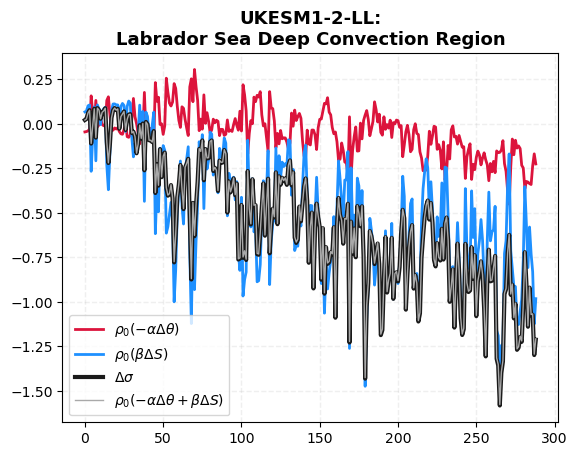

In [12]:
plt.figure()
plt.grid(True, lw=1, ls='--', alpha=0.2)
plt.plot(dsigma0_approx_diathermal[:, 7].cumsum(), lw=2, color='crimson', label='$\\rho_{0} (-\\alpha \\Delta \\theta)$')
plt.plot(dsigma0_approx_diahaline[:, 7].cumsum(), lw=2, color='dodgerblue', label='$\\rho_{0} (\\beta \\Delta S )$')
plt.plot(dsigma0_actual[:, 7].cumsum(), lw=3, color='0.1', label='$\\Delta \\sigma$')
plt.plot(dsigma0_approx[:, 7].cumsum(), lw=1, color='darkgrey', label='$\\rho_{0} (-\\alpha \\Delta \\theta + \\beta \\Delta S)$')

plt.title('UKESM1-2-LL:\nLabrador Sea Deep Convection Region', fontweight='bold', fontsize=13)
plt.legend(loc='lower left')

(3.0, 12.0)

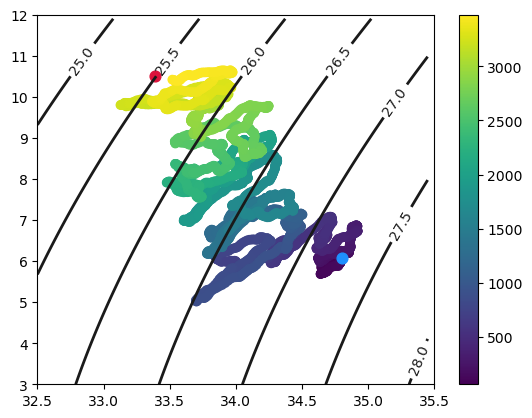

In [13]:
thetao_con_ref = np.arange(3, 12, 0.1)
so_abs_ref = np.arange(32.5, 35.5, 0.05)
so_abs_grid, thetao_con_grid = np.meshgrid(so_abs_ref, thetao_con_ref)
sigma0_grid = gsw.sigma0(CT=thetao_con_grid, SA=so_abs_grid)

# T-S Evoluation (5-year rolling mean):
scatter = plt.scatter(ds_ukesm1_up2p0['so_abs_LabSea'][:, 0].rolling(time_counter=60).mean(),
                      ds_ukesm1_up2p0['thetao_con_LabSea'][:, 0].rolling(time_counter=60).mean(),
                      c=np.arange(ds_ukesm1_up2p0['time_counter'].size)
                      )
plt.colorbar(scatter)

# Initial year:
plt.scatter(ds_ukesm1_up2p0['so_abs_LabSea'].isel(k=0, time_counter=slice(0, 12)).mean(), ds_ukesm1_up2p0['thetao_con_LabSea'].isel(k=0, time_counter=slice(0, 12)).mean(), s=60, color='dodgerblue')
# Final year:
plt.scatter(ds_ukesm1_up2p0['so_abs_LabSea'].isel(k=0, time_counter=slice(-12, None)).mean(), ds_ukesm1_up2p0['thetao_con_LabSea'].isel(k=0, time_counter=slice(-12, None)).mean(), s=60, color='crimson')

# Potential density contours:
contour = plt.contour(so_abs_grid, thetao_con_grid, sigma0_grid, levels=[25, 25.5, 26, 26.5, 27., 27.5, 28], linewidths=2, colors='0.1')
plt.clabel(contour, levels=contour.levels, fontsize=10)

plt.xlim([32.5, 35.5])
plt.ylim([3, 12])

Yr=0 ->  370.6884765625
Yr=46 ->  69.02168273925781


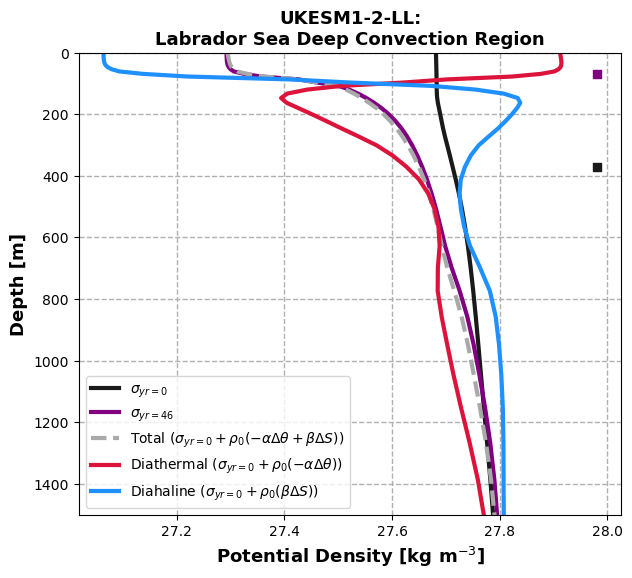

In [14]:
plt.figure(figsize=(7, 6))
plt.grid(True, lw=1, ls='--')

nyr = 46 # 61

plt.plot(ds_ukesm1_up2p0['sigma0_LabSea'].isel(time_counter=(2)), ds_ukesm1_up2p0['deptht'], lw=3, label='$\\sigma_{yr=0}$', color='0.1')
plt.scatter([27.98], mld_LabSea.isel(time_counter=[2]), s=35, color='0.1', marker='s')
plt.plot(ds_ukesm1_up2p0['sigma0_LabSea'].isel(time_counter=(nyr*12)+2), ds_ukesm1_up2p0['deptht'], lw=3, label='$\\sigma_{yr=46}$', color='purple')
plt.scatter([27.98], mld_LabSea.isel(time_counter=[(nyr*12)+2]), s=35, color='purple', marker='s')

plt.plot(ds_ukesm1_up2p0['sigma0_LabSea'].isel(time_counter=2) + dsigma0_approx.isel(time_counter=slice(None, nyr)).sum(dim='time_counter'), ds_ukesm1_up2p0['deptht'], lw=3, ls='--', color='darkgrey', label='Total ($\\sigma_{yr=0} + \\rho_{0} (-\\alpha \\Delta \\theta + \\beta \\Delta S)$)')
plt.plot(ds_ukesm1_up2p0['sigma0_LabSea'].isel(time_counter=2) + dsigma0_approx_diathermal.isel(time_counter=slice(None, nyr)).sum(dim='time_counter'), ds_ukesm1_up2p0['deptht'], lw=3, color='crimson', label='Diathermal ($\\sigma_{yr=0} + \\rho_{0} (-\\alpha \\Delta \\theta)$)')
plt.plot(ds_ukesm1_up2p0['sigma0_LabSea'].isel(time_counter=2) + dsigma0_approx_diahaline.isel(time_counter=slice(None, nyr)).sum(dim='time_counter'), ds_ukesm1_up2p0['deptht'], lw=3, color='dodgerblue', label='Diahaline ($\\sigma_{yr=0} + \\rho_{0} (\\beta \\Delta S)$)')

print('Yr=0 -> ', mld_LabSea[2].item())
print(f'Yr={nyr} -> ', mld_LabSea[(nyr*12)+2].item())

plt.legend()
plt.title('UKESM1-2-LL:\nLabrador Sea Deep Convection Region', fontweight='bold', fontsize=13)
plt.xlabel('Potential Density [kg m$^{-3}$]', fontweight='bold', fontsize=13)
plt.ylabel('Depth [m]', fontweight='bold', fontsize=13)
plt.ylim([1500, 0])

# Save Figure:
plt.savefig("/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/figures/M26/fig_M26_LabSea_sigma0_profiles.png", bbox_inches='tight', dpi=600)


In [20]:
ds_ukesm1_up2p0['sigma0_LabSea'].isel(time_counter=(2))[:25]
ds_ukesm1_up2p0['sigma0_LabSea'].isel(time_counter=(46*12)+2)[:25]

<xarray.DataArray 'sigma0_LabSea' (k: 25)> Size: 200B
array([27.29206059, 27.29210019, 27.29218699, 27.2922619 , 27.29232568,
       27.29238136, 27.29243312, 27.29248188, 27.29253405, 27.29258969,
       27.29265116, 27.2927238 , 27.29283817, 27.29300442, 27.29327753,
       27.293773  , 27.29469296, 27.29642887, 27.29972537, 27.30593164,
       27.32501867, 27.35652495, 27.42655831, 27.46031641, 27.50101998])
Coordinates:
  * k             (k) int64 200B 1 2 3 4 5 6 7 8 9 ... 18 19 20 21 22 23 24 25
    deptht        (k) float64 200B 0.5058 1.556 2.668 ... 86.93 97.04 108.0
    variable      <U2 8B ...
    time_counter  object 8B 0046-03-16 00:00:00
Attributes:
    standard_name:  wmean_labsea_seawater_absolute_salinity_profile
    long_name:      Vertical Profile of Labrador Sea Convection Region Volume...
    units:          g kg-1

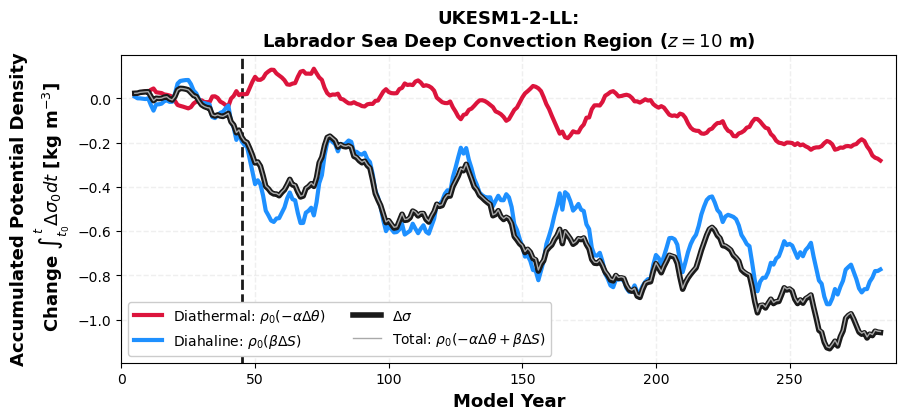

In [15]:
# -- Accumulated Change in Potential Density at 10 m -- #
plt.figure(figsize=(10, 4))
nk=7
nyr=10
plt.axvline(x=45, lw=2, ls='--', color='0.1')
plt.grid(True, lw=1, ls='--', alpha=0.2)

plt.plot(dsigma0_approx_diathermal[:, nk].cumsum(dim='time_counter').rolling(time_counter=nyr, center=True).mean(), lw=3, color='crimson', label='Diathermal: $\\rho_{0} (-\\alpha \\Delta \\theta)$')
plt.plot(dsigma0_approx_diahaline[:, nk].cumsum(dim='time_counter').rolling(time_counter=nyr, center=True).mean(), lw=3, color='dodgerblue', label='Diahaline: $\\rho_{0} (\\beta \\Delta S )$')
plt.plot(dsigma0_actual[:, nk].cumsum(dim='time_counter').rolling(time_counter=nyr, center=True).mean(), lw=4, color='0.1', label='$\\Delta \\sigma$')
plt.plot(dsigma0_approx[:, nk].cumsum(dim='time_counter').rolling(time_counter=nyr, center=True).mean(), lw=1, color='darkgrey', label='Total: $\\rho_{0} (-\\alpha \\Delta \\theta + \\beta \\Delta S)$')

plt.title('UKESM1-2-LL:\nLabrador Sea Deep Convection Region ($z = 10$ m)', fontweight='bold', fontsize=13)
plt.xlabel('Model Year', fontweight='bold', fontsize=13)
plt.xlim([0, 290])
plt.ylabel('Accumulated Potential Density\n Change $\\int_{t_{0}}^{t} \\Delta \\sigma_{0} dt$ [kg m$^{-3}$]', fontweight='bold', fontsize=13)
plt.legend(ncols=2, loc='lower left', fancybox=True, framealpha=1)

# Save Figure:
plt.savefig("/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/figures/M26/fig_M26_LabSea_sigma0_10m_timeseries.png", bbox_inches='tight', dpi=600)


### Irminger Sea

In [16]:
# -- Calculating Mixed Layer Depth (0.03 kg m-3 threshold criterion from 10 m potential density) directly from profiles -- #
# Irminger Sea:
mask_IrmSea_MLD = (ds_ukesm1_up2p0['sigma0_IrmSea'] - ds_ukesm1_up2p0['sigma0_IrmSea'].isel(k=7)) > 0.03
mld_IrmSea = ds_ukesm1_up2p0.deptht.where(mask_IrmSea_MLD).min(dim='k')

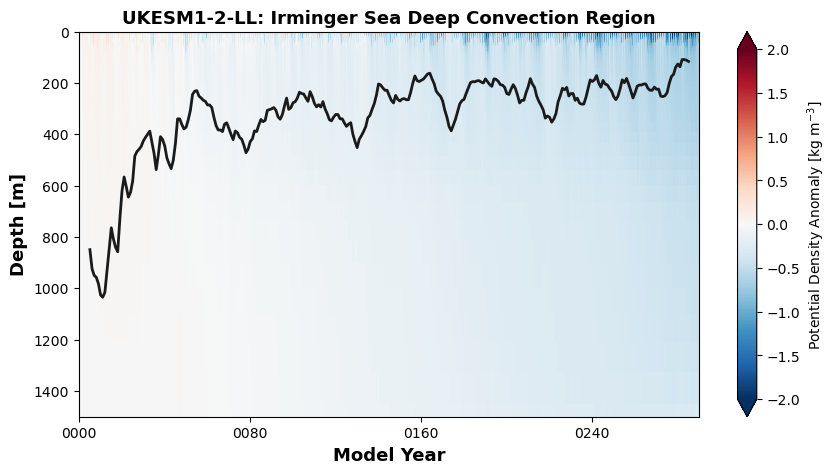

In [17]:
# Calculate monthly climatology of potential density in esm-piControl:
sigma0_IrmSea_piControl_monthly = (ds_ukesm1_piControl['sigma0_IrmSea']
                                   .groupby(ds_ukesm1_piControl['time_counter'].dt.month)
                                   .mean()
                                   )
# -- Potential Density -- #
plt.figure(figsize=(10, 5))
((ds_ukesm1_up2p0['sigma0_IrmSea'].groupby(ds_ukesm1_up2p0['time_counter'].dt.month) - sigma0_IrmSea_piControl_monthly)
 .transpose()
 .plot(yincrease=False, y='deptht', vmin=-2, vmax=2, cmap='RdBu_r', extend='both', cbar_kwargs={'label': 'Potential Density Anomaly [kg m$^{-3}$]'})
 )

# March Mixed Layer Depth [10-year rolling mean]:
mld_IrmSea.isel(time_counter=slice(2, None, 12)).rolling(time_counter=10, center=True).mean().plot(lw=2, color='0.1')

plt.title('UKESM1-2-LL: Irminger Sea Deep Convection Region', fontweight='bold', fontsize=13)
plt.xlabel('Model Year', fontweight='bold', fontsize=13)
plt.ylabel('Depth [m]', fontweight='bold', fontsize=13)
plt.ylim([1500, 0])
# Save Figure:
plt.savefig("/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/figures/M26/fig_M26_IrmSea_MLD_sigma0.png", bbox_inches='tight', dpi=600)
